---
title: Satellogic Processing Workflow
description: This notebook demonstrates the complete workflow for downloading and processing Sentinel-2 satellite imagery using the `disasters-product-algorithms` package. 
author: 
  - Ethan Kerr (Editor, UAH)
  - Kyle Lesinger (Editor, UAH)
date: May 1, 2025
execute:
   freeze: true
---

# Run This Notebook

<h3><a href="https://hub.disasters.2i2c.cloud/hub/user-redirect/git-pull?repo=https://github.com/Disasters-Learning-Portal/disasters-docs&urlpath=lab/tree/disasters-docs/Jupyterhub/simple_disaster_template.ipynb&branch=main">🚀 Launch in Disasters-Hub JupyterHub (requires access)</a></h3>

<h4> To obtain credentials to VEDA Hub, <a href = "https://docs.openveda.cloud/user-guide/scientific-computing/getting-access.html"> follow this link for more information.</a></h4>

<div class="alert alert-block" style="
     background-color: #f8d7da;
     color: #721c24;
     border-left: 4px solid #28a745;
  ">
Disclaimer: it is highly recommended to run a tutorial within NASA VEDA JupyterHub, which already includes functions for processing and visualizing data specific to VEDA stories. Running the tutorial outside of the VEDA JupyterHub may lead to errors, specifically related to EarthData authentication. Additionally, it is recommended to use the Pangeo workspace within the VEDA JupyterHub, since certain packages relevant to this tutorial are already installed. </div>

<h4> If you <strong>do not</strong> have a VEDA Jupyterhub Account you can launch this notebook on your local environment using MyBinder by clicking the icon below.</h4>
<br/>
<a href="https://binder.openveda.cloud/v2/gh/NASA-IMPACT/veda-docs/9c8cdbae92906fb7062b8a0c759dad90e223a4f9?urlpath=lab%2Ftree%2Fuser-guide%2Fnotebooks%2Fstories%2Fderechos.ipynb">
<img src="https://binder.openveda.cloud/badge_logo.svg" alt="Binder" title="A cute binder" width="150"/> </a>

## Table of Contents
- [Satellogic Processing Workflow](#satellogic-processing-workflow)
- [Environment Setup](#environment-setup)
- [Process Satellogic Data](#process-satellogic-data)
- [View Results](#view-results)
- [Next Steps](#next-steps)

# Satellogic Processing Workflow #

This notebook demonstrates the complete workflow for downloading and processing Satellogic imagery using the `disasters-product-algorithms` package.

## Workflow Steps
1. **Configure Environment Variables** - Set processing parameters
2. **Process Satellogic Data** - Generate products with COG conversion
3. **View Results** - Examine the generated outputs

## Features Demonstrated
- Cloud Optimized GeoTIFF (COG) conversion
- Multiple product generation (true color, color IR, NDVI, NDWI, EVI)
- Cloud masking
- Gamma correction

# Environment Setup #

Configure all processing parameters as environment variables for easy modification.

In [10]:
import os
import subprocess

# Data selection
DATE = "2026-04-23 12:00:00" # The nearest available date will be selected
LEVEL = "L1D"  #L1B or L1D (Level 1D has more processing)

# Product flags: choose True for products that you want to generate
PRODUCTS = {
    "truecolor": True,
    "colorir": False,
    "ndvi": False,
    "ndwi": False,
    "evi": False
}

# Processing flags
# Apply a cloud mask
USE_MASK = True

# RGB enhancement toggle: select true if you would like band normalization and Gamma correction to enhance contrast
RGB_ENHANCEMENT = {
    "truecolor": True,
    "colorir": True
}

GAMMA = 2.2   # only used when RGB_ENHANCEMENT is True: higher Gamma increases composite image contrast

# Output settings
OUTPUT_DIR = "/tmp/satellogic_output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# COG settings
COMPRESSION = "ZSTD"
COMPRESSION_LEVEL = 22
NODATA = 0

print("Configuration:")
print(f"  Date: {DATE}")
print(f"  Level: {LEVEL}")
print(f"  Products: {PRODUCTS}")
print(f"  Output Directory: {OUTPUT_DIR}")
print(f"  RGB Enhancement Enabled: {RGB_ENHANCEMENT}")
print(f"  Gamma: {GAMMA}")
print(f"  Cloud Mask: {USE_MASK}")

Configuration:
  Date: 2026-04-23 12:00:00
  Level: L1D
  Products: {'truecolor': True, 'colorir': False, 'ndvi': False, 'ndwi': False, 'evi': False}
  Output Directory: /tmp/satellogic_output
  RGB Enhancement Enabled: {'truecolor': True, 'colorir': True}
  Gamma: 2.2
  Cloud Mask: True


# Process Satellogic Data #

Process the downloaded imagery to generate various products with COG conversion and event naming.

**Note:** The processing script has been configured to display progress in real-time within JupyterHub. You'll see:
- Detailed product generation steps
- COG conversion progress
- Error messages if any products fail
- Final processing summary with success/failure counts
- Log file location for detailed error tracking

In [11]:
process_cmd = [
    "process_satellogic",
    "-h"
]

help_flags = subprocess.run(process_cmd, cwd=os.getcwd())
print(help_flags)

usage: process_satellogic [-h] --product {truecolor,colorir,ndvi,ndwi,evi}
                          --date DATE --level LEVEL [--output OUTPUT]
                          [--use_mask] [--visualize] [--gamma GAMMA]
                          [-nodata NODATA] [-compression COMPRESSION]
                          [-compression_level COMPRESSION_LEVEL]

Process Satellogic imagery

options:
  -h, --help            show this help message and exit
  --product {truecolor,colorir,ndvi,ndwi,evi}
                        Product to generate
  --date DATE           Target datetime (YYYY-MM-DD HH:MM:SS)
  --level LEVEL         Processing level (e.g. L1D, L1B)
  --output OUTPUT
  --use_mask            Apply cloud mask
  --visualize           Apply normalization + gamma correction for RGB
                        products only
  --gamma GAMMA         Gamma correction for RGB products (default 0.7)
  -nodata NODATA
  -compression COMPRESSION
  -compression_level COMPRESSION_LEVEL
CompletedProcess(args=['p

In [12]:
for PRODUCT, ENABLED in PRODUCTS.items():

    if not ENABLED:
        continue

    process_cmd = [
        "process_satellogic",
        "--product", PRODUCT,
        "--date", DATE,
        "--level", LEVEL,
        "--output", OUTPUT_DIR,
        "-compression", COMPRESSION,
        "-compression_level", str(COMPRESSION_LEVEL)
    ]

    if USE_MASK:
        process_cmd.append("--use_mask")

    if PRODUCT in RGB_ENHANCEMENT and RGB_ENHANCEMENT[PRODUCT]:
        process_cmd.append("--visualize")
        process_cmd.extend(["--gamma", str(GAMMA)])

    # NDVI / NDWI / EVI:
    # no gamma, no enhancement, no filtering
    if NODATA is not None:
        process_cmd.extend(["-nodata", str(NODATA)])

    print(f"\nProcessing Satellogic product: {PRODUCT}")
    print(f"Command: {' '.join(process_cmd)}\n")

    process = subprocess.Popen(
        process_cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1
    )

    for line in process.stdout:
        print(line, end='')

    return_code = process.wait()

    if return_code == 0:
        print(f"\n✓ {PRODUCT} completed successfully!")
    else:
        print(f"\n✗ {PRODUCT} failed ({return_code})")


Processing Satellogic product: truecolor
Command: process_satellogic --product truecolor --date 2026-04-23 12:00:00 --level L1D --output /tmp/satellogic_output -compression ZSTD -compression_level 22 --use_mask --visualize --gamma 2.2 -nodata 0

/srv/conda/envs/notebook/lib/python3.12/site-packages/satellogic/satellogic_v2.py:199: RuntimeWarning: invalid value encountered in cast
  out_img = (rgb * 255).astype(np.uint8)
Retrieving Satellogic resources...
Generating truecolor...
Detected processing level: L1D
Using default scale factor: 0.0001
Skipping solar correction for L1D.

Converting to COG...
  Data type: uint8
  No-data value: 0.0
  Source CRS: EPSG:32614
  Target CRS: EPSG:4326
  Reprojection: Required
  Compression: ZSTD (level 22)
  Overview levels: 5
  Resampling method: cubic (auto-detected)
  Warping to EPSG:4326...
  Creating COG: 202604_Satellogic_L1D_truecolor_2026-04-24T22:41:58Z.tif.cog.tmp.tif
  ✓ COG created: 202604_Satellogic_L1D_truecolor_2026-04-24T22:41:58Z.tif

# View Results #

Examine the generated output files and directory structure.


Found 2 outputs


Displaying: 202604_273_ndwi_2026-04-24T22:41:58Z.tif


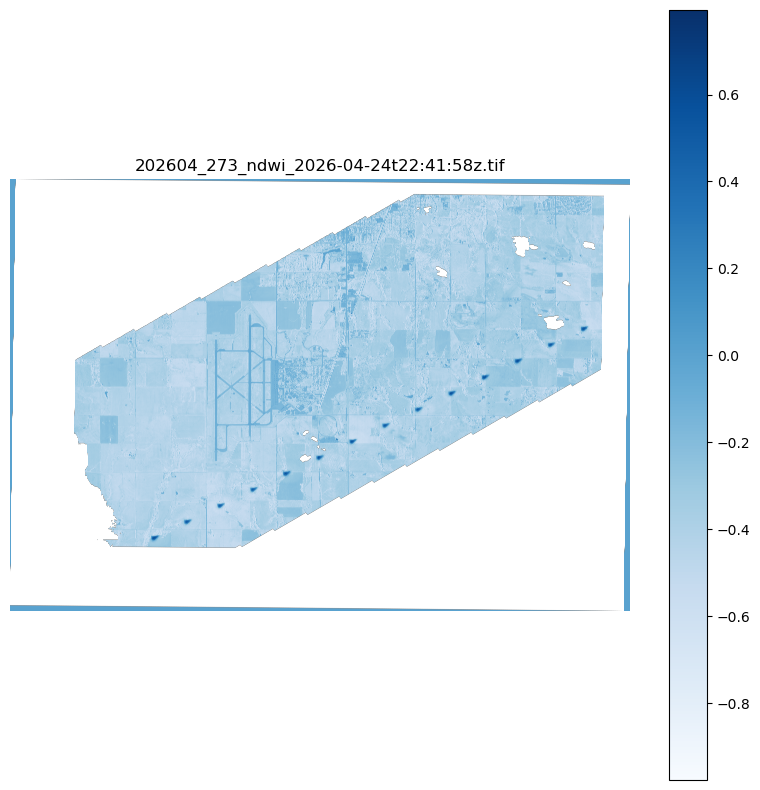

✓ Plotted 202604_273_ndwi_2026-04-24T22:41:58Z.tif

Displaying: 202604_273_truecolor_2026-04-24T22:41:58Z.tif


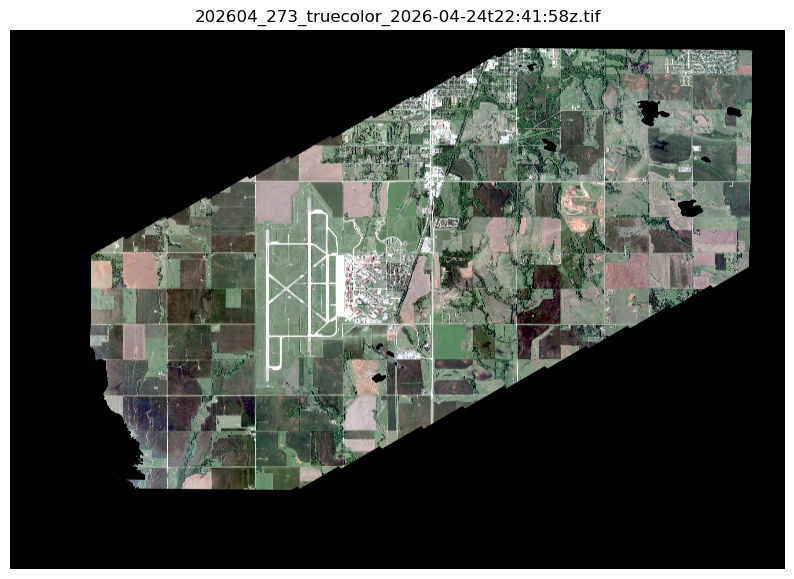

✓ Plotted 202604_273_truecolor_2026-04-24T22:41:58Z.tif


In [6]:
import glob
import rasterio
import matplotlib.pyplot as plt
import numpy as np

output_dir = os.path.abspath(OUTPUT_DIR)

tif_files = sorted([
    f for f in glob.glob(os.path.join(output_dir, "**/*.tif"), recursive=True)
    if not f.endswith(".tmp.tif")
])

print(f"\nFound {len(tif_files)} outputs\n")

for tif_file in tif_files:

    print(f"\nDisplaying: {os.path.basename(tif_file)}")

    with rasterio.open(tif_file) as src:

        plt.figure(figsize=(10, 10))

        filename = os.path.basename(tif_file).lower()

        # RGB products (composite images)
        if src.count >= 3:

            arr = src.read([1, 2, 3]).astype(float)
            arr = np.transpose(arr, (1, 2, 0))

            if "truecolor" in filename or "colorir" in filename:
                arr = np.clip(arr / 255.0, 0, 1)

            else:
                band_min = np.min(arr, axis=(0, 1))
                band_max = np.max(arr, axis=(0, 1))
                arr = (arr - band_min) / (band_max - band_min + 1e-6)
                arr = np.clip(arr, 0, 1)

            plt.imshow(arr)
            plt.title(filename)
            plt.axis("off")
            plt.show()

        # Single band products (indices)
        # You can adjust vmin and vmax for each index for visualization to increase image contrast
        else:
            arr = src.read(1).astype(float)

            if "ndvi" in filename:
                cmap = "RdYlGn"
                arr = np.where((arr < -1) | (arr > 1), np.nan, arr)
                im = plt.imshow(arr, cmap=cmap, vmin=-0.5, vmax=0.5)

            elif "ndwi" in filename:
                cmap = "Blues"
                arr = np.where((arr < -1) | (arr > 1), np.nan, arr)
                im = plt.imshow(arr, cmap=cmap)

            elif "evi" in filename:
                cmap = "viridis"
                arr = np.where((arr < -1) | (arr > 1), np.nan, arr)
                im = plt.imshow(arr, cmap=cmap, vmin=-0.5, vmax=0.5)

            else:
                im = plt.imshow(arr, cmap="viridis")

            plt.colorbar(im)
            plt.title(filename)
            plt.axis("off")
            plt.show()

    print(f"✓ Plotted {os.path.basename(tif_file)}")

# Next Steps #

You can now:
1. Load and visualize the GeoTIFF files using libraries like `rasterio` or `GDAL`
2. Upload the COG files to cloud storage (S3, GCS, etc.)
3. Process additional dates or tiles by modifying the configuration variables
4. Generate additional products by updating the `PRODUCTS` list